# Mr. John Cena

In [1]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib.patches import Patch
import duckdb
import pandas as pd

In [2]:
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

In [3]:
cur.execute("""
SELECT 
    s.superstar_name,
    YEAR(m.Date) AS Year,
    e.EventType,
    COUNT(*) AS MatchCount,
    ROUND(AVG(m.CageMatchRating), 2) AS AvgRating,
    SUM(m.CageMatchRatingVotes) AS TotalVotes
FROM superstars s
JOIN match_rating m ON s.MatchIndex = m.Index
JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
WHERE s.superstar_name ILIKE '%cena%'
  AND m.CageMatchRating IS NOT NULL
GROUP BY s.superstar_name, Year, e.EventType
ORDER BY Year ASC;
""")

In [4]:
# Save query from all superstars in Wrestlemania with most viewed total votes
df = cur.df()

# Print the first five rows
df

,superstar_name,Year,EventType,MatchCount,AvgRating,TotalVotes
0,John Cena,2015,PLE/PPV,12,6.93,3093.0
1,John Cena,2015,Televised,39,6.76,4538.0
2,John Cena,2015,Non-Televised,7,6.09,682.0
3,John Cena,2016,Televised,8,7.22,1495.0
4,John Cena,2016,PLE/PPV,4,7.93,1429.0
5,John Cena,2017,Non-Televised,10,5.43,1172.0
6,John Cena,2017,Televised,14,6.20,686.0
7,John Cena,2017,PLE/PPV,14,5.56,3598.0
8,John Cena,2018,Televised,11,6.84,586.0
9,John Cena,2018,Non-Televised,6,5.21,623.0


# Draft 1

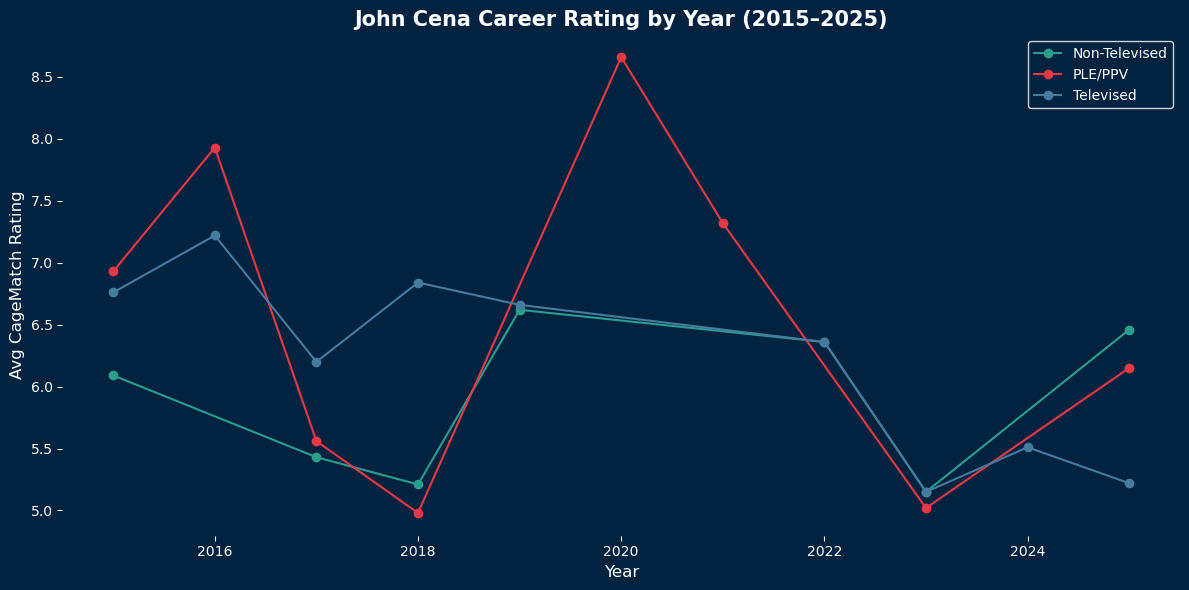

In [5]:
import matplotlib.pyplot as plt

bg_color = "#022340"
colors = {"PLE/PPV": "#e63946", "Televised": "#457b9d", "Non-Televised": "#2a9d8f"}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

for etype, group in df.groupby("EventType"):
    ax.plot(group["Year"], group["AvgRating"], 
            marker="o", label=etype, color=colors.get(etype, "white"))

ax.set_xlabel("Year", color="white", fontsize=12)
ax.set_ylabel("Avg CageMatch Rating", color="white", fontsize=12)
ax.set_title("John Cena Career Rating by Year (2015–2025)", 
             color="white", fontsize=15, fontweight="bold")
ax.tick_params(colors="white")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.legend(facecolor=bg_color, labelcolor="white", edgecolor="white")

plt.tight_layout()
plt.show()

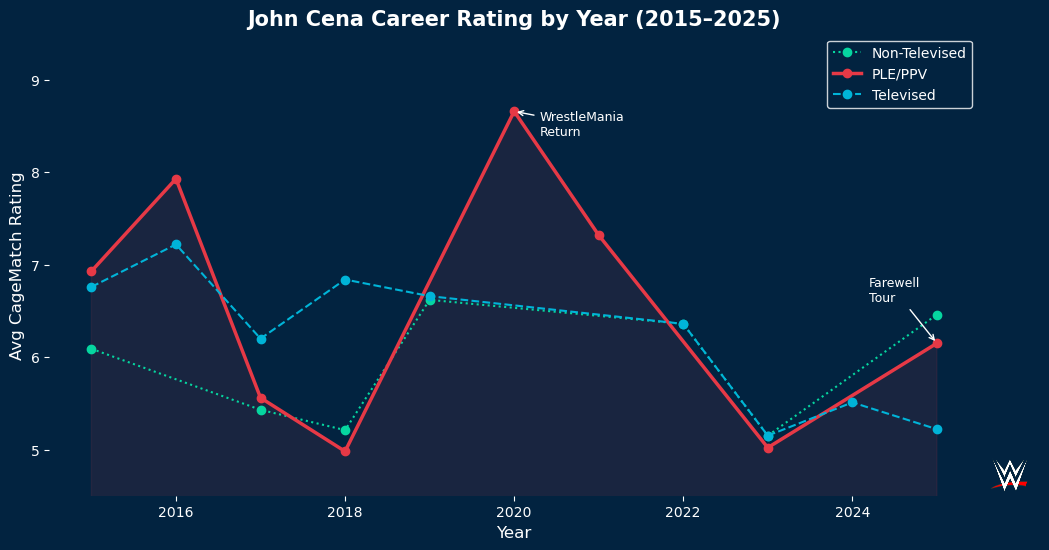

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
colors = {"PLE/PPV": "#e63946", "Televised": "#00B4D8", "Non-Televised": "#06D6A0"}


line_styles = {"PLE/PPV": "-", "Televised": "--", "Non-Televised": ":"}
line_widths = {"PLE/PPV": 2.5, "Televised": 1.5, "Non-Televised": 1.5}

for etype, group in df.groupby("EventType"):
    group = group.sort_values("Year")
    ax.plot(group["Year"], group["AvgRating"],
            marker="o", label=etype,
            color=colors.get(etype),
            linestyle=line_styles[etype],
            linewidth=line_widths[etype])
    
    # Shade under PLE/PPV line
    if etype == "PLE/PPV":
        ax.fill_between(group["Year"], group["AvgRating"], 
                        alpha=0.1, color=colors["PLE/PPV"])

# Annotate 2020 peak
ax.annotate("WrestleMania\nReturn", xy=(2020, 8.66),
            xytext=(2020.3, 8.4), color="white", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white", lw=1))

# Annotate 2025 farewell
ax.annotate("Farewell\nTour", xy=(2025, 6.15),
            xytext=(2024.2, 6.6), color="white", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white", lw=1))

ax.set_xlabel("Year", color="white", fontsize=12)
ax.set_ylabel("Avg CageMatch Rating", color="white", fontsize=12)
ax.set_title("John Cena Career Rating by Year (2015–2025)",
             color="white", fontsize=15, fontweight="bold")
ax.tick_params(colors="white")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.legend(facecolor=bg_color, labelcolor="white", edgecolor="white")

ax.set_ylim(4.5, 9.5)

# Add LOGO
logo = imread('../images/WWE-logo.png')
logo_ax = fig.add_axes([0.90, 0.02, 0.05, 0.25])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")

# Save Plot
plt.savefig('../images/john_cena_ratings.png', dpi=150)

plt.show()

# Close Connection

In [7]:
conn.close()